In [26]:
import numpy as np

In [27]:
class KMeans:
    def __init__(self, n_clusters: int = 3, max_iter: int = 300, tol: float = 1e-4, random_state: int = 314):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.rng = np.random.default_rng(random_state)
        self.centroids = None
        self.labels = None
    
    def _init_centroids(self, X: np.ndarray) -> None:
        n_samples, _ = X.shape
        idx = self.rng.choice(n_samples, self.n_clusters, replace=False)
        self.centroids = X[idx]
    
    def _assign_clusters(self, X: np.ndarray) -> None:
        n_samples, _ = X.shape
        distances = np.zeros((n_samples, self.n_clusters))
        
        for i, centroid in enumerate(self.centroids):
            distances[:, i] = np.sum((X - centroid) ** 2, axis=1)
        
        self.labels = np.argmin(distances, axis=1)
    
    def _update_centroids(self, X: np.ndarray) -> None:
        _, n_features = X.shape
        
        new_centroids = np.zeros((self.n_clusters, n_features))
        for i in range(self.n_clusters):
            cluster_points = X[self.labels == i]
            if len(cluster_points) > 0:
                new_centroids[i] = np.mean(cluster_points, axis=0)
            else:
                new_centroids[i] = self.centroids[i]
        
        self.centroids = new_centroids

    def fit(self, X: np.ndarray) -> None:
        self._init_centroids(X)
        
        for _ in range(self.max_iter):
            old_centroids = self.centroids.copy()
            self._assign_clusters(X)
            self._update_centroids(X)
            
            if np.allclose(old_centroids, self.centroids, atol=self.tol):
                break
    
    def predict(self, X: np.ndarray) -> np.ndarray:
        n_samples, _ = X.shape
        distances = np.zeros((n_samples, self.n_clusters))
        for i, centroid in enumerate(self.centroids):
            distances[:, i] = np.sum((X - centroid)**2, axis=1)
        
        return np.argmin(distances, axis=1)

In [28]:
from sklearn.datasets import load_iris, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt

In [29]:
iris = load_iris()

features = iris.feature_names

print(features)

X = iris.data[:, [2, 3]]

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [31]:
kmeans = KMeans()

kmeans.fit(X_scaled)

labels = kmeans.labels
centroids = kmeans.centroids

In [32]:
sil = silhouette_score(X_scaled, labels)
ari = adjusted_rand_score(iris.target, labels)
print(f"silhouette = {sil:.3f} | ARI = {ari:.3f}")

silhouette = 0.674 | ARI = 0.886


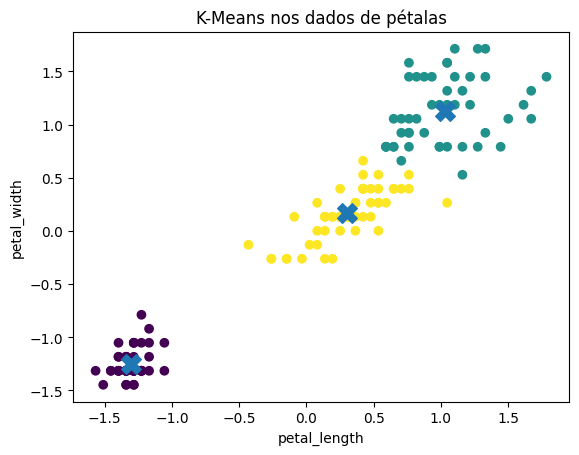

In [33]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels)
plt.scatter(centroids[:,0], centroids[:,1], marker='X', s=200)
plt.title('K-Means nos dados de pétalas')
plt.xlabel('petal_length')
plt.ylabel('petal_width')
plt.show()

In [34]:
import pandas as pd

wine = load_iris()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target
df["class"] = df["target"].map({i:n for i, n in enumerate(wine.target_names)})

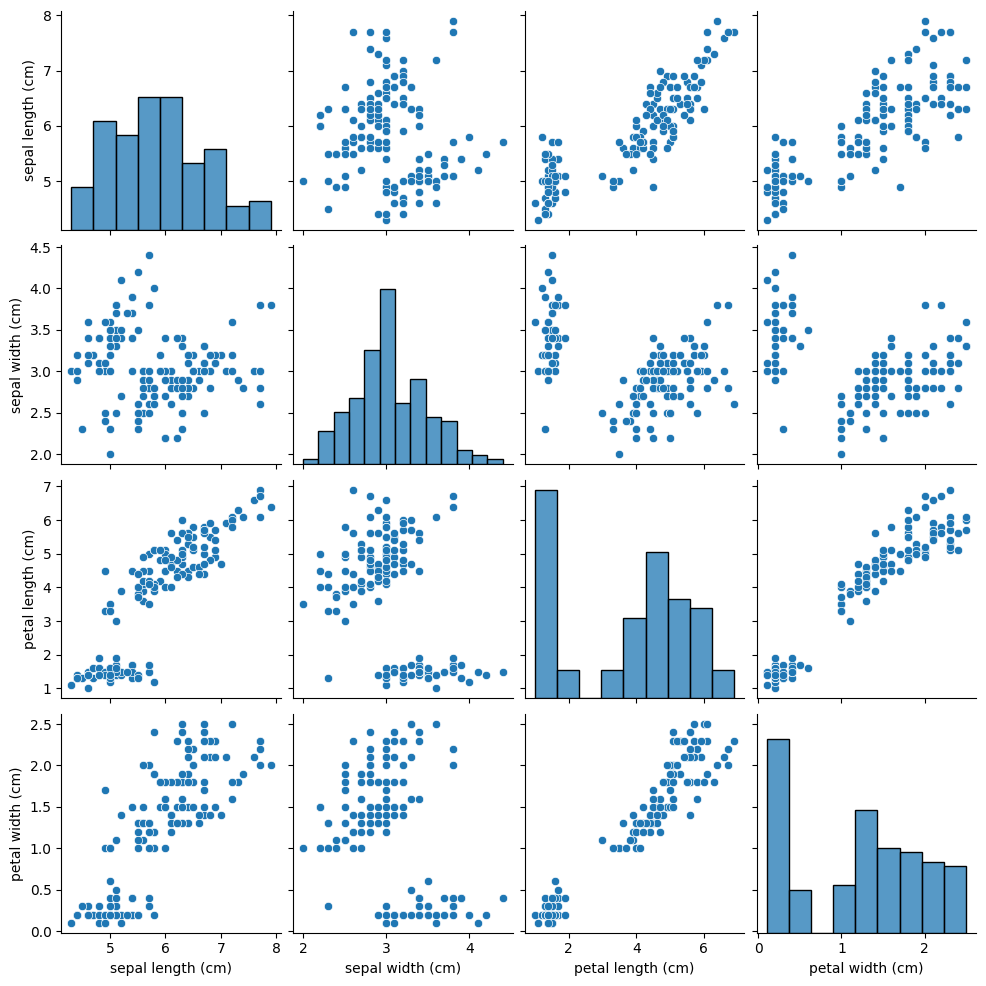

In [35]:
import seaborn as sns

feat_cols = wine.feature_names
sns.pairplot(df[feat_cols], diag_kind="hist")

silhouette = 0.524 | ARI = 0.831


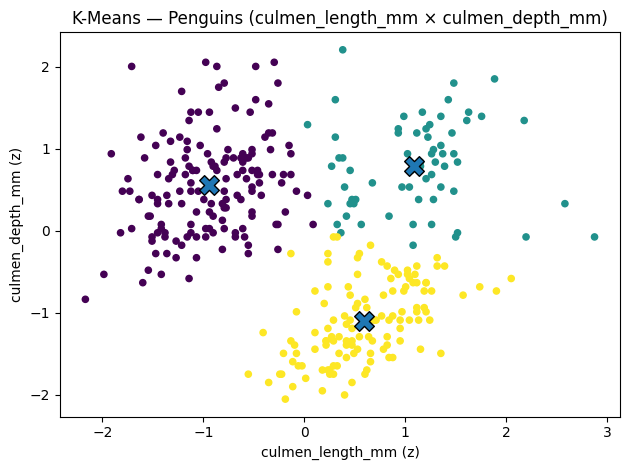

In [36]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt

penguins = fetch_openml("penguins", as_frame=False)
features = penguins.feature_names

cols = [1, 2]
X_raw = penguins.data[:, cols].astype(float)   # (n, 2)
y_raw = np.asarray(penguins.target)            # (n,)

maskX = np.isfinite(X_raw).all(axis=1)

X = X_raw[maskX]
y = y_raw[maskX]

maskY = np.array([val == val for val in y])
if not maskY.all():
    X = X[maskY]
    y = y[maskY]

X_scaled = StandardScaler().fit_transform(X)
k = KMeans()
k.fit(X_scaled)

labels = k.labels
centroids = k.centroids

sil = silhouette_score(X_scaled, labels)
ari = adjusted_rand_score(y, labels)
print(f"silhouette = {sil:.3f} | ARI = {ari:.3f}")

x_name = features[cols[0]]
y_name = features[cols[1]]

plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, s=20)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, edgecolor='k', linewidths=1.0)
plt.title(f'K-Means — Penguins ({x_name} × {y_name})')
plt.xlabel(f'{x_name} (z)')
plt.ylabel(f'{y_name} (z)')
plt.tight_layout()
plt.show()
